# Nasdaq Analysis during War periods

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


In [3]:
nasdaq = yf.download("^IXIC", period="50y")
nasdaq.columns = nasdaq.columns.get_level_values(0)
nasdaq = nasdaq.reset_index()
nasdaq

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,1976-05-14,89.779999,89.779999,89.779999,89.779999,0
1,1976-05-17,89.489998,89.489998,89.489998,89.489998,0
2,1976-05-18,89.529999,89.529999,89.529999,89.529999,0
3,1976-05-19,89.250000,89.250000,89.250000,89.250000,0
4,1976-05-20,89.529999,89.529999,89.529999,89.529999,0
...,...,...,...,...,...,...
12598,2026-05-07,25806.199219,26036.380859,25713.650391,25881.300781,9118880000
12599,2026-05-08,26247.080078,26248.619141,25944.779297,25958.119141,9577150000
12600,2026-05-11,26274.130859,26359.310547,26129.830078,26135.630859,11989910000
12601,2026-05-12,26088.199219,26190.480469,25739.220703,26087.009766,9631840000


In [4]:
nasdaq["daily_return"] = nasdaq["Close"].pct_change()*100
nasdaq.head()

Price,Date,Close,High,Low,Open,Volume,daily_return
0,1976-05-14,89.779999,89.779999,89.779999,89.779999,0,NaN
1,1976-05-17,89.489998,89.489998,89.489998,89.489998,0,-0.323013
2,1976-05-18,89.529999,89.529999,89.529999,89.529999,0,0.044699
3,1976-05-19,89.250000,89.250000,89.250000,89.250000,0,-0.312743
4,1976-05-20,89.529999,89.529999,89.529999,89.529999,0,0.313724


In [5]:
avg_return = nasdaq["daily_return"].mean()
# The Gulf War occurred from August 2, 1990, to February 28, 1991. We will filter the data for this period and calculate the average return during the Gulf War.
gulf_war = nasdaq[(nasdaq["Date"] >= "1990-08-02") & (nasdaq["Date"] <= "1991-02-28")]
avg_gulf_return = gulf_war["daily_return"].mean()

print(f'The average return of Nasdaq of past 50 years is {avg_return}')
print(f'The average return during Gulf War is {avg_gulf_return}')

The average return of Nasdaq of past 50 years is 0.05366227765469331
The average return during Gulf War is 0.034781261294764


In [6]:
# Perform a two tailed z-test to determine if the average return during the Gulf War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_gulf_return
sample_size = len(gulf_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value}')
print(f'At a significance level of 0.05, we {"reject" if p_value < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.')

Standard Error: 0.10814663154914826
Z-score: -0.17458718861112796
P-value: 0.861404015977034
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.


Text(0, 0.5, 'Close Price')

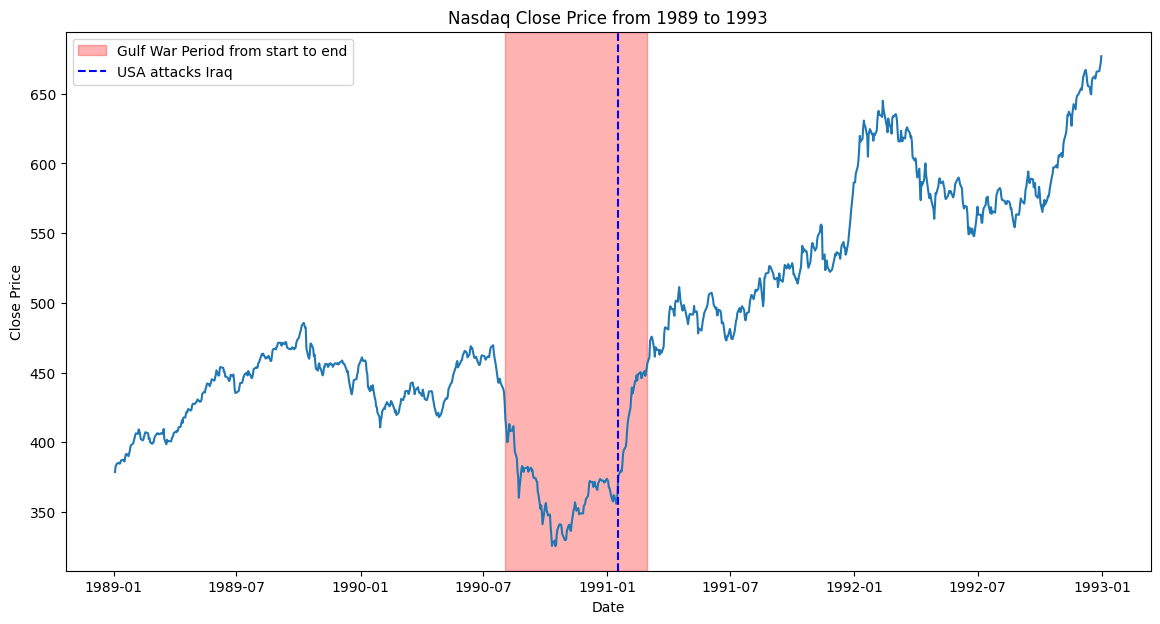

In [7]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "1989-01-01") & (nasdaq["Date"] <= "1993-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("1990-08-02", "1991-02-28", alpha=0.3, color="red", label="Gulf War Period from start to end")
plt.axvline(x=pd.to_datetime("1991-01-17"), color="blue", linestyle="--", label="USA attacks Iraq")
plt.legend()
plt.title("Nasdaq Close Price from 1989 to 1993")
plt.xlabel("Date")
plt.ylabel("Close Price")